# Taller 05 – Modelos de Regresión
**Autora:** Ana María López  
**Objetivo:** Predecir el precio de venta de automóviles usados utilizando tres modelos de regresión: Regresión Lineal, Árbol de Decisión y Random Forest.  
**Dataset:** `cardekho.csv` contiene información sobre autos usados (marca, año, tipo de combustible, transmisión, kilometraje, precio, etc.).  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el archivo CSV
df = pd.read_csv("cardekho.csv")

# Ver las primeras filas
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [3]:
# Información general
df.info()

# Revisar valores nulos
df.isnull().sum()

# Eliminar columnas irrelevantes
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Eliminar filas con valores nulos
df = df.dropna()

# Convertir variables categóricas
df = pd.get_dummies(df, drop_first=True)

# Verificar resultado
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 762.1 KB


,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats,name_Ambassador Classic 2000 DSZ AC PS,name_Ambassador Grand 1500 DSZ BSIII,name_Ambassador Grand 2000 DSZ PW CL,name_Ashok Leyland Stile LE,...,max_power_98.59,max_power_98.6,max_power_98.63,max_power_98.79,max_power_98.82,max_power_98.96,max_power_98.97,max_power_99,max_power_99.23,max_power_99.6
0,2014,450000,145500,23.40,1248.0,5.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2014,370000,120000,21.14,1498.0,5.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2006,158000,140000,17.70,1497.0,5.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2010,225000,127000,23.00,1396.0,5.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2007,130000,120000,16.10,1298.0,5.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [4]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
models = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

resultados = {}

for nombre, modelo in models.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    resultados[nombre] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "R²": r2_score(y_test, y_pred)
    }

pd.DataFrame(resultados).T


,MAE,MSE,R²
Regresión Lineal,172494.798222,1.198850e+11,0.839631
Árbol de Decisión,71560.486390,2.074135e+10,0.972255
Random Forest,66328.757493,1.872125e+10,0.974957


C:\Users\Ana Maria Lopez\AppData\Local\Temp\ipykernel_33252\1061435815.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=res_df.index, y=res_df["R²"], palette="Blues_d")


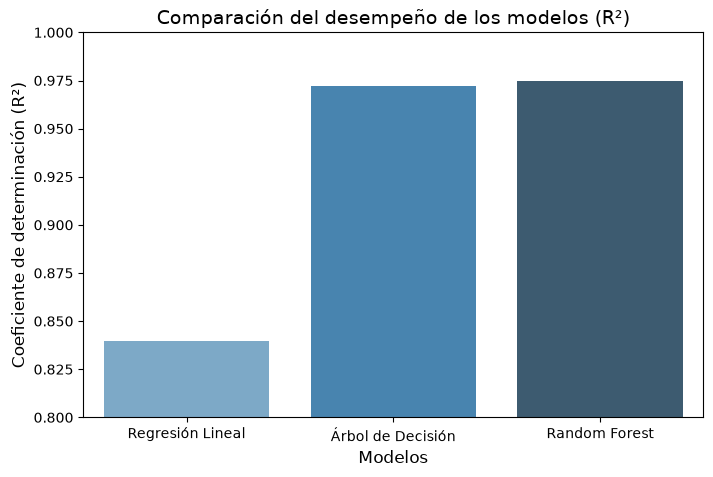

In [7]:
res_df = pd.DataFrame(resultados).T

plt.figure(figsize=(8,5))
sns.barplot(x=res_df.index, y=res_df["R²"], palette="Blues_d")
plt.title("Comparación del desempeño de los modelos (R²)", fontsize=14)
plt.ylabel("Coeficiente de determinación (R²)", fontsize=12)
plt.xlabel("Modelos", fontsize=12)
plt.ylim(0.8, 1.0)
plt.show()



### Conclusiones
El modelo **Random Forest** obtuvo el mejor desempeño con un \(R^2\) cercano a 0.975, seguido por el **Árbol de Decisión**.  
Ambos modelos capturan muy bien la relación entre las variables y el precio de los autos.  
La **Regresión Lineal**, aunque más simple, mostró un desempeño aceptable y puede ser útil como referencia base.  
En general, los modelos basados en árboles ofrecen mayor precisión para este tipo de datos no lineales.
